In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio

In [2]:
pio.renderers.default = "notebook"

In [2]:
df = pd.read_csv(
    "../data/processed/birth_probability.csv"
)

In [3]:
# Log transform
df["LogShare"] = np.log10(df["BirthProbability"].clip(lower=1e-5))
lower = df["LogShare"].quantile(0.10)
upper = df["LogShare"].max()

In [4]:
# Color Design
BIRTH_COLORSCALE = [
    [0.00, "#0D0B1F"],
    [0.14, "#2D1A56"],
    [0.28, "#5C2C84"],
    [0.43, "#9B2B70"],
    [0.58, "#CA4535"],
    [0.71, "#E8742A"],  
    [0.83, "#F5A623"],   
    [0.92, "#FAD066"],   
    [1.00, "#FFF8DC"],   
]


BG     = "#05090F"
OCEAN  = "#080F1A"
LAND   = "#101E2E"
BORDER = "#1E2F42"
TEXT   = "#C9D6E2"
DIM    = "#5A7690"
ACCENT = "#F5A623"

In [6]:
# Figure
fig = px.choropleth(
    df,
    locations="Country Code",
    color="LogShare",
    hover_name="Country Name",
    hover_data={
        "BirthProbability": ":.3f",
        "Births":           ":,.0f",
        "Rank":             True,
        "Country Code":     False,
        "LogShare":         False,
    },
    animation_frame="Year",
    color_continuous_scale=BIRTH_COLORSCALE,
    range_color=(lower, upper),
)

In [7]:
# Trace styling
fig.update_traces(
    marker_line_color=BORDER,
    marker_line_width=0.35,
)
for frame in fig.frames:
    for trace in frame.data:
        trace.marker.line.color = BORDER
        trace.marker.line.width = 0.35

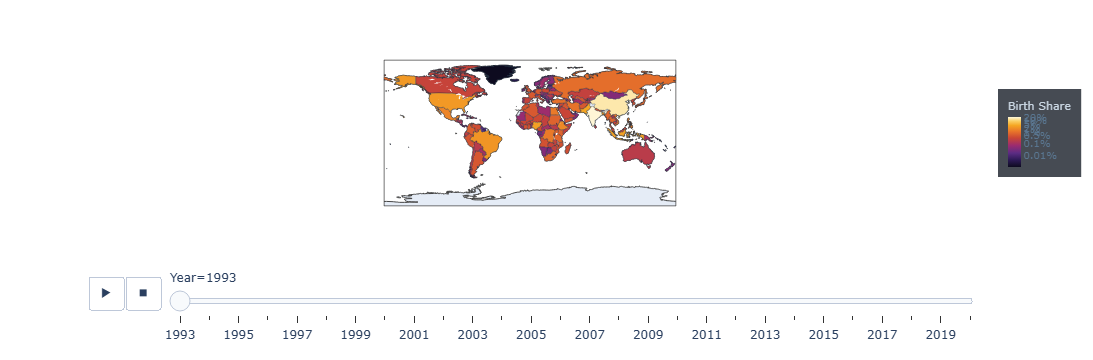

In [8]:
# Colorbar
fig.update_coloraxes(
    colorbar=dict(
        title=dict(
            text="Birth Share",
            font=dict(size=11, color=TEXT),
        ),
        tickmode="array",
        tickvals=[np.log10(x) for x in [0.01, 0.1, 0.5, 1, 2, 5, 10, 20]],
        ticktext=["0.01%", "0.1%", "0.5%", "1%", "2%", "5%", "10%", "20%"],
        tickfont=dict(size=10, color=DIM),
        thickness=13,
        len=0.60,
        x=1.02,
        bgcolor="rgba(8,15,26,0.75)",
        outlinewidth=0,
        borderwidth=0,
    )
)


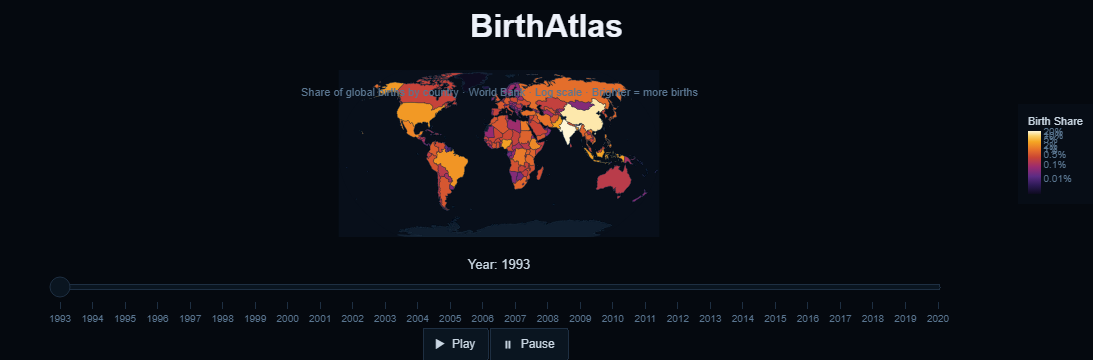

In [9]:
# Layout

fig.update_layout(
    paper_bgcolor=BG,
    font=dict(family="Inter, Arial, sans-serif", color=TEXT),

    title=dict(
        text="<b>BirthAtlas</b>",
        x=0.5,
        xanchor="center",
        y=0.96,
        font=dict(size=32, color="#EEF2FA"),
    ),

    annotations=[dict(
        text="Share of global births by country · World Bank · Log scale · Brighter = more births",
        x=0.5, y=0.915,
        xref="paper", yref="paper",
        showarrow=False,
        font=dict(size=11, color=DIM),
        xanchor="center",
    )],

    geo=dict(
        bgcolor=OCEAN,
        showocean=True,       oceancolor=OCEAN,
        showland=True,        landcolor=LAND,
        showlakes=False,      showrivers=False,
        showcoastlines=True,  coastlinecolor=BORDER,  coastlinewidth=0.4,
        showframe=False,
        showcountries=True,   countrycolor=BORDER,    countrywidth=0.3,
        projection_type="natural earth",
    ),

    margin=dict(l=0, r=90, t=70, b=60),

    sliders=[dict(
        currentvalue=dict(
            prefix="Year: ",
            font=dict(size=13, color=TEXT),
            visible=True,
            xanchor="center",
        ),
        pad=dict(t=15, b=5),
        font=dict(color=DIM, size=10),
        bgcolor="#0A1520",
        activebgcolor=ACCENT,
        bordercolor=BORDER,
        tickcolor=BORDER,
        x=0.05,
        len=0.9,
    )],

    updatemenus=[dict(
        type="buttons",
        showactive=False,
        y=-0.12,
        x=0.5,
        xanchor="center",
        buttons=[
            dict(
                label="▶  Play",
                method="animate",
                args=[None, dict(frame=dict(duration=450, redraw=True), fromcurrent=True)],
            ),
            dict(
                label="⏸  Pause",
                method="animate",
                args=[[None], dict(frame=dict(duration=0, redraw=False), mode="immediate")],
            ),
        ],
        font=dict(color=TEXT, size=12),
        bgcolor="#0A1520",
        bordercolor=BORDER,
    )],
)

fig.show()

In [10]:
# Stats (dynamic from data)
n_countries   = df["Country Code"].nunique()
year_min      = int(df["Year"].min())
year_max      = int(df["Year"].max())
avg_births    = df.groupby("Year")["Births"].sum().mean()
births_label  = f"{avg_births/1e6:.0f}M" if avg_births < 1e9 else f"{avg_births/1e9:.1f}B"

# ── Export figure as embeddable div ────────────────────────────────────
# Note: default_height/width passed explicitly so Plotly does not collapse
# to 0px when the surrounding container has no intrinsic height.
fig_div = fig.to_html(
    full_html=False,
    include_plotlyjs=False,
    div_id="birth-atlas-map",
    default_height="720px",
    default_width="100%",
    config={
        "displayModeBar": True,
        "modeBarButtonsToRemove": ["select2d", "lasso2d", "toImage"],
        "displaylogo": False,
        "responsive": True,
    },
)


In [14]:
# HTML template
html_page = f"""<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8" />
  <meta name="viewport" content="width=device-width, initial-scale=1.0" />
  <title>BirthAtlas — Where Life Begins</title>
  <meta name="description" content="Interactive visualization of global birth probability by country." />
  <link rel="preconnect" href="https://fonts.googleapis.com" />
  <link href="https://fonts.googleapis.com/css2?family=Space+Grotesk:wght@300;400;600;700&display=swap" rel="stylesheet" />
  <script src="https://cdn.plot.ly/plotly-3.1.0.min.js" charset="utf-8"></script>
  <style>
    *, *::before, *::after {{ box-sizing: border-box; margin: 0; padding: 0; }}
    :root {{
      --bg:     #05090F;
      --surf:   #0C1626;
      --bdr:    #1A2A3C;
      --text:   #C9D6E2;
      --dim:    #5A7690;
      --accent: #F5A623;
      --font:   'Space Grotesk', 'Inter', Arial, sans-serif;
    }}
    html, body {{ background: var(--bg); color: var(--text); font-family: var(--font); min-height: 100vh; }}

    body::before {{
      content: '';
      position: fixed; inset: 0;
      background-image:
        radial-gradient(1px 1px at 12% 22%, rgba(255,255,255,.18) 0%, transparent 100%),
        radial-gradient(1px 1px at 52% 68%, rgba(255,255,255,.12) 0%, transparent 100%),
        radial-gradient(1px 1px at 78% 15%, rgba(255,255,255,.15) 0%, transparent 100%),
        radial-gradient(1px 1px at 36% 82%, rgba(255,255,255,.10) 0%, transparent 100%),
        radial-gradient(1px 1px at 68% 40%, rgba(255,255,255,.13) 0%, transparent 100%),
        radial-gradient(1px 1px at 90% 60%, rgba(255,255,255,.08) 0%, transparent 100%),
        radial-gradient(1px 1px at 25% 55%, rgba(255,255,255,.09) 0%, transparent 100%);
      pointer-events: none; z-index: 0;
    }}

    header, .stats, .map-wrapper, footer {{ position: relative; z-index: 1; }}

    header {{ text-align: center; padding: 56px 24px 24px; }}

    .logo {{
      font-size: clamp(40px, 7vw, 70px);
      font-weight: 700;
      letter-spacing: -2.5px;
      color: #EEF2FA;
      line-height: 1;
    }}
    .logo span {{ color: var(--accent); }}

    .tagline {{
      margin-top: 13px;
      font-size: clamp(13px, 1.8vw, 15px);
      font-weight: 300;
      color: var(--dim);
      letter-spacing: 0.5px;
    }}

    .divider {{
      width: 44px; height: 2px;
      background: linear-gradient(90deg, transparent, var(--accent), transparent);
      margin: 24px auto 0;
      opacity: 0.8;
    }}

    .stats {{
      display: flex;
      justify-content: center;
      gap: clamp(28px, 5vw, 72px);
      padding: 30px 24px 22px;
      flex-wrap: wrap;
    }}
    .stat {{ text-align: center; }}
    .stat-value {{
      font-size: clamp(20px, 3vw, 26px);
      font-weight: 600;
      color: #E5ECF5;
      letter-spacing: -0.5px;
    }}
    .stat-label {{
      font-size: 10px;
      color: var(--dim);
      text-transform: uppercase;
      letter-spacing: 2px;
      margin-top: 4px;
    }}

    .map-wrapper {{
      width: 100%;
      max-width: 1440px;
      margin: 0 auto;
      padding: 0 16px 52px;
    }}
    #birth-atlas-map {{
      width: 100%;
      height: 720px;
      min-height: 520px;
      border-radius: 10px;
      border: 1px solid var(--bdr);
      background: var(--surf);
      overflow: hidden;
    }}
    #birth-atlas-map .plot-container,
    #birth-atlas-map .svg-container {{
      width: 100% !important;
      height: 100% !important;
    }}

    footer {{
      border-top: 1px solid var(--bdr);
      padding: 28px 24px;
      text-align: center;
      font-size: 12px;
      color: var(--dim);
      line-height: 2;
    }}
    footer a {{ color: var(--accent); text-decoration: none; opacity: 0.75; }}
    footer a:hover {{ opacity: 1; }}
    .footer-note {{ display: block; margin-top: 5px; font-size: 11px; opacity: 0.4; }}
  </style>
</head>
<body>
  <header>
    <div class="logo">Birth<span>Atlas</span></div>
    <div class="tagline">Where in the world were you most likely to be born?</div>
    <div class="divider"></div>
  </header>

  <div class="stats">
    <div class="stat">
      <div class="stat-value">{n_countries}</div>
      <div class="stat-label">Countries</div>
    </div>
    <div class="stat">
      <div class="stat-value">{year_min}–{year_max}</div>
      <div class="stat-label">Time Range</div>
    </div>
    <div class="stat">
      <div class="stat-value">~{births_label}</div>
      <div class="stat-label">Births / Year</div>
    </div>
    <div class="stat">
      <div class="stat-value">World Bank</div>
      <div class="stat-label">Data Source</div>
    </div>
  </div>

  <div class="map-wrapper">
    {fig_div}
  </div>

  <footer>
    Data: <a href="https://data.worldbank.org/" target="_blank" rel="noopener">World Bank Open Data</a>
    &nbsp;·&nbsp; Built with Python · pandas · Plotly &nbsp;·&nbsp;
    <a href="https://github.com/YOUR_USERNAME/BirthAtlas" target="_blank" rel="noopener">View on GitHub</a>
    <span class="footer-note">
      Birth probability = each country's share of estimated global births · Log scale applied
    </span>
  </footer>
</body>
</html>"""

with open("../index.html", "w", encoding="utf-8") as f:
    f.write(html_page)

print(f"✅ index.html exported — {n_countries} countries · {year_min}–{year_max}")

✅ index.html exported — 215 countries · 1993–2020
